In [1]:
# Cell 1 — load clean data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

df = pd.read_csv("../data/master_df_clean.csv")
df["order_purchase_timestamp"] = pd.to_datetime(df["order_purchase_timestamp"])

reference_date = df["order_purchase_timestamp"].max()
print("Data loaded:", df.shape)
print("Reference date:", reference_date)

Data loaded: (113422, 25)
Reference date: 2018-10-17 17:30:18


In [2]:
# Cell 2 — build RFM table at customer level
rfm = df.groupby("customer_unique_id").agg(
    recency=("order_purchase_timestamp", lambda x: (reference_date - x.max()).days),
    frequency=("order_id", "nunique"),
    monetary=("total_payment", "sum")
).reset_index()

print("RFM table shape:", rfm.shape)
print("\nFirst 5 rows:")
print(rfm.head())
print("\nRFM summary stats:")
print(rfm[["recency", "frequency", "monetary"]].describe())

RFM table shape: (96095, 4)

First 5 rows:
                 customer_unique_id  recency  frequency  monetary
0  0000366f3b9a7992bf8c76cfdf3221e2      160          1    141.90
1  0000b849f77a49e4a4ce2b2a4ca5be3f      163          1     27.19
2  0000f46a3911fa3c0805444483337064      585          1     86.22
3  0000f6ccb0745a6a4b88665a16c9f078      369          1     43.62
4  0004aac84e0df4da2b147fca70cf8255      336          1    196.89

RFM summary stats:
            recency     frequency       monetary
count  96095.000000  96095.000000   96095.000000
mean     287.730756      1.034809     213.025929
std      153.407846      0.214385     640.920050
min        0.000000      1.000000       0.000000
25%      163.000000      1.000000      63.990000
50%      268.000000      1.000000     113.150000
75%      397.000000      1.000000     202.735000
max      772.000000     17.000000  109312.640000


In [3]:
# Cell 3 — score R, F, M each 1 to 5
# Recency: lower days = better = higher score
rfm["R_score"] = pd.qcut(rfm["recency"], q=5, labels=[5, 4, 3, 2, 1])

# Frequency: higher orders = better = higher score
rfm["F_score"] = pd.qcut(rfm["frequency"].rank(method="first"), q=5, labels=[1, 2, 3, 4, 5])

# Monetary: higher spend = better = higher score
rfm["M_score"] = pd.qcut(rfm["monetary"].rank(method="first"), q=5, labels=[1, 2, 3, 4, 5])

# Convert to int
rfm["R_score"] = rfm["R_score"].astype(int)
rfm["F_score"] = rfm["F_score"].astype(int)
rfm["M_score"] = rfm["M_score"].astype(int)

# Combined RFM score
rfm["RFM_score"] = rfm["R_score"] + rfm["F_score"] + rfm["M_score"]

print("Scores added ✓")
print(rfm[["R_score", "F_score", "M_score", "RFM_score"]].head(10))

Scores added ✓
   R_score  F_score  M_score  RFM_score
0        4        1        4          9
1        4        1        1          6
2        1        1        2          4
3        2        1        1          4
4        2        1        4          7
5        4        1        4          9
6        4        1        1          6
7        3        1        5          9
8        1        1        4          6
9        4        1        3          8


In [4]:
# Cell 4 — assign segment labels based on RFM score
def assign_segment(row):
    r = row["R_score"]
    f = row["F_score"]
    m = row["M_score"]
    score = row["RFM_score"]
    
    if r >= 4 and f >= 4 and m >= 4:
        return "Champions"
    elif r >= 3 and f >= 3:
        return "Loyal"
    elif r >= 4 and f <= 2:
        return "Promising"
    elif r <= 2 and f >= 3:
        return "At Risk"
    elif r <= 2 and f <= 2 and m <= 2:
        return "Lost"
    else:
        return "Needs Attention"

rfm["segment"] = rfm.apply(assign_segment, axis=1)

print("Segment distribution:")
print(rfm["segment"].value_counts())
print("\nSegment percentages:")
print(round(rfm["segment"].value_counts(normalize=True) * 100, 2))

Segment distribution:
segment
Loyal              28002
At Risk            22966
Needs Attention    16515
Promising          15448
Champions           6689
Lost                6475
Name: count, dtype: int64

Segment percentages:
segment
Loyal              29.14
At Risk            23.90
Needs Attention    17.19
Promising          16.08
Champions           6.96
Lost                6.74
Name: proportion, dtype: float64


In [5]:
# Cell 5 — calculate Customer Lifetime Value
# CLV = average order value x purchase frequency x estimated lifespan (years)
# Lifespan estimated as 2 years (standard for e-commerce)

rfm["avg_order_value"] = rfm["monetary"] / rfm["frequency"]
rfm["purchase_frequency"] = rfm["frequency"] / rfm["frequency"].sum()
rfm["CLV"] = rfm["avg_order_value"] * rfm["frequency"] * 2

print("CLV calculated ✓")
print("\nCLV by segment:")
print(rfm.groupby("segment")["CLV"].mean().sort_values(ascending=False).round(2))

CLV calculated ✓

CLV by segment:
segment
Champions          895.72
Needs Attention    533.38
At Risk            428.18
Promising          410.02
Loyal              330.05
Lost               112.99
Name: CLV, dtype: float64


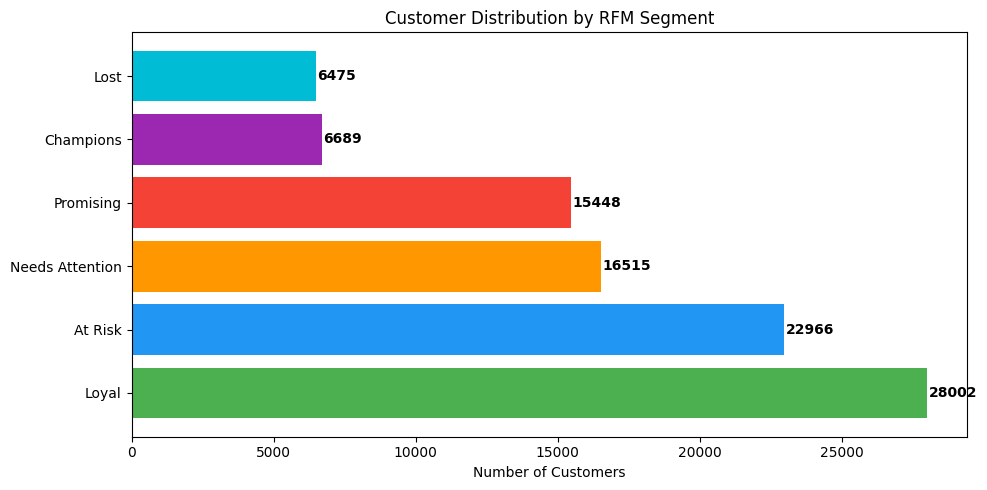

Chart 6 saved ✓


In [6]:
# Cell 6 — visualise segments
plt.figure(figsize=(10, 5))

segment_counts = rfm["segment"].value_counts()
colors = ["#4CAF50", "#2196F3", "#FF9800", "#F44336", "#9C27B0", "#00BCD4"]

plt.barh(segment_counts.index, segment_counts.values, color=colors)
plt.xlabel("Number of Customers")
plt.title("Customer Distribution by RFM Segment")
for i, v in enumerate(segment_counts.values):
    plt.text(v + 50, i, str(v), va="center", fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/chart6_rfm_segments.png", dpi=150)
plt.show()
print("Chart 6 saved ✓")

C:\Users\FAYAS\AppData\Local\Temp\ipykernel_17704\3184812287.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=clv_by_segment.values, y=clv_by_segment.index, palette="YlOrRd_r")


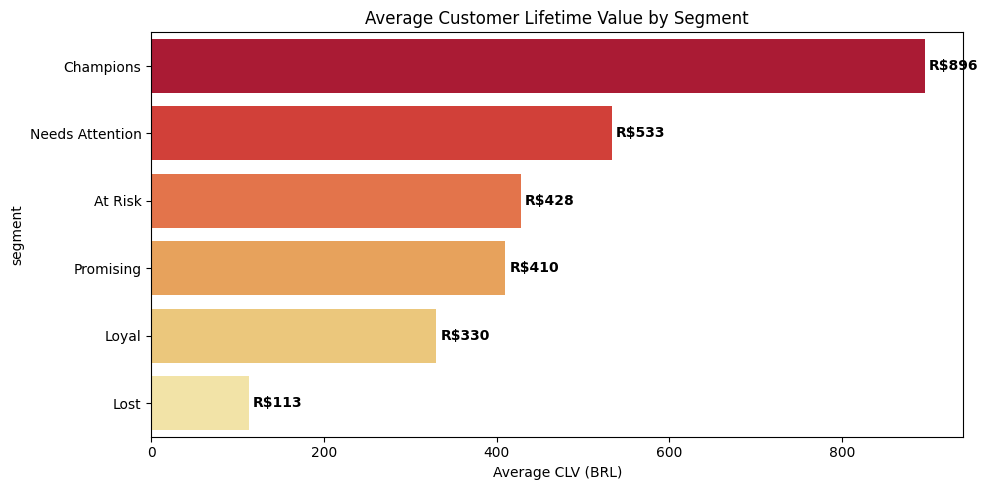

Chart 7 saved ✓


In [7]:
# Cell 7 — CLV by segment chart
plt.figure(figsize=(10, 5))

clv_by_segment = rfm.groupby("segment")["CLV"].mean().sort_values(ascending=False)

sns.barplot(x=clv_by_segment.values, y=clv_by_segment.index, palette="YlOrRd_r")
plt.xlabel("Average CLV (BRL)")
plt.title("Average Customer Lifetime Value by Segment")
for i, v in enumerate(clv_by_segment.values):
    plt.text(v + 5, i, f"R${v:.0f}", va="center", fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/chart7_clv_by_segment.png", dpi=150)
plt.show()
print("Chart 7 saved ✓")

In [8]:
# Cell 8 — merge RFM back into master and save
df_final = df.merge(rfm[["customer_unique_id", "R_score", "F_score", "M_score", 
                           "RFM_score", "segment", "CLV"]], 
                    on="customer_unique_id", how="left")

df_final.to_csv("../data/master_df_rfm.csv", index=False)
rfm.to_csv("../data/rfm_table.csv", index=False)

print("Files saved ✓")
print("master_df_rfm shape:", df_final.shape)
print("\nRFM table shape:", rfm.shape)
print("\nAll outputs:")
for f in os.listdir("../outputs"):
    print(" ✓", f)

Files saved ✓
master_df_rfm shape: (113422, 31)

RFM table shape: (96095, 12)

All outputs:
 ✓ chart1_churn_by_category.png
 ✓ chart2_order_frequency.png
 ✓ chart3_revenue_churn.png
 ✓ chart4_review_vs_churn.png
 ✓ chart5_payment_vs_churn.png
 ✓ chart6_rfm_segments.png
 ✓ chart7_clv_by_segment.png
